In [18]:
from math import sin
from math import pi
from numpy import arange
from numpy import argmax
from numpy.random import normal
from matplotlib import pyplot
from numpy import asarray
from numpy.random import random
from warnings import catch_warnings
from warnings import simplefilter
from sklearn.gaussian_process import GaussianProcessRegressor

In [4]:
# Objective function with noise
def objective(x, noise = 0.1):
  noise = normal(loc = 0, scale = noise)
  return (x**2 * sin(5 * pi * x)**6) + noise

In [5]:
# Grid-based sample of the domain [0,1]
X = arange(0, 1, 0.01)
print(X)

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]


In [6]:
# We can then evaluate these samples using the objective function without
# any noise to see what the real objective function looks like
y = [objective(x,0) for x in X]
print(y)

[np.float64(0.0), np.float64(1.4655297809619805e-09), np.float64(3.483005625052574e-07), np.float64(7.879943409141711e-06), np.float64(6.598300562505258e-05), np.float64(0.0003124999999999999), np.float64(0.0010093652949374528), np.float64(0.0024517793587195947), np.float64(0.004736067977499789), np.float64(0.007519770412501646), np.float64(0.010000000000000002), np.float64(0.01123323728287283), np.float64(0.01065615294937453), np.float64(0.008456136971910446), np.float64(0.005495433272437245), np.float64(0.002812500000000001), np.float64(0.0010557280900008426), np.float64(0.00025303373836021753), np.float64(2.821234556292591e-05), np.float64(5.290562509272771e-07), np.float64(1.3493515170493364e-97), np.float64(6.462986334042298e-07), np.float64(4.2144368063136055e-05), np.float64(0.00046316556260399575), np.float64(0.0023753882025018902), np.float64(0.007812499999999996), np.float64(0.0189536372049366), np.float64(0.03647647250013438), np.float64(0.058016832724372414), np.float64(0.0

In [7]:
# We can then evaluate these same points with noise to see what the objective
# function will look like when we are optimizing it
ynoise = [objective(x) for x in X]
print(ynoise)

[np.float64(0.1665923680888354), np.float64(-0.059832638288421065), np.float64(-0.11294978416008904), np.float64(0.08243529990506651), np.float64(0.00428083017636151), np.float64(-0.06986175316716572), np.float64(-0.021019352058018373), np.float64(0.02157936224674825), np.float64(-0.03728490482660953), np.float64(0.12532246289246854), np.float64(0.07707353291423599), np.float64(0.06051909684941721), np.float64(0.0020867885441485726), np.float64(0.12750651757698636), np.float64(-0.031486544430137306), np.float64(0.07618773700948461), np.float64(-0.07549436061886668), np.float64(0.07595436656248272), np.float64(-0.07138640949926735), np.float64(0.09415038200373296), np.float64(-0.03468612760797831), np.float64(-0.0651810004039362), np.float64(-0.005027189303541362), np.float64(0.0849321294735151), np.float64(0.134859292684578), np.float64(0.09668262794550868), np.float64(-0.14820719943308194), np.float64(0.16557606856915894), np.float64(0.05945974879790187), np.float64(-0.040109257585899

In [8]:
# Look at all the non-noisy objective function values to find the input
# that resulted in the best score. This will be the optima, in this case,
# maxima, as we are maximizing the output of the objective function.
# We would not know this in practice, but for our test problem, it is
# good to know the real best input and output of the function to see if
# the Bayesian Optimization algorithm can locate it
ix = argmax(y)
print('Optima: x = %.3f, y = %.3f' % (X[ix], y[ix]))

Optima: x = 0.900, y = 0.810


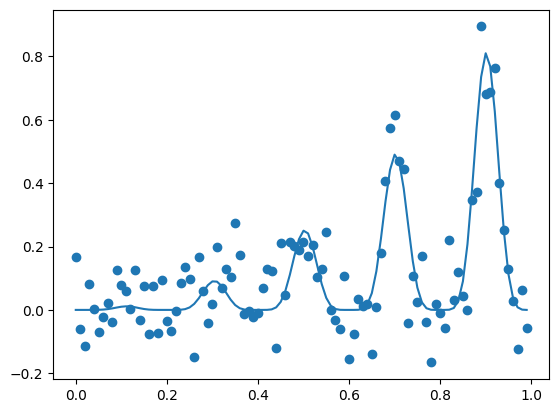

In [14]:
# plot the points with noise
pyplot.scatter(X, ynoise)
# plot the points without noise
pyplot.plot(X, y)
# show the plot
pyplot.show()

Now that we have a test problem, lets see **how** to train a surrogate function

In [ ]:
# This is often best modeled using a random forest or a Gaussian Process
# GP regression model is often preferred